In [1]:

from pathlib import Path

import pandas

In [2]:
scopus_result_path = Path("scopus_results/export_72789020-e75f-4a08-8fcb-4bccf2e087b9_2026-03-13T095412.332136263.csv")
df = pandas.read_csv(scopus_result_path)
df[df["DOI"].isna()]

,Authors,Author full names,Author(s) ID,Title,Year,Source title,Volume,Issue,Art. No.,Page start,...,ISBN,CODEN,PubMed ID,Language of Original Document,Abbreviated Source Title,Document Type,Publication Stage,Open Access,Source,EID
96,Wiebe N.; Kapoor A.; Svore K.M.,"Wiebe, Nathan (35369512500); Kapoor, Ashish (3...",35369512500; 36856640700; 55898617400,Quantum algorithms for nearest-neighbor method...,2015,Quantum Information and Computation,15,3-4,NaN,318.0,...,NaN,NaN,NaN,English,Quantum Inf. Comput.,Article,Final,NaN,Scopus,2-s2.0-84910071253
115,Wiebe N.; Kapoor A.; Svore K.M.,"Wiebe, Nathan (35369512500); Kapoor, Ashish (3...",35369512500; 36856640700; 55898617400,Quantum deep learning,2016,Quantum Information and Computation,16,7-8,NaN,541.0,...,NaN,NaN,NaN,English,Quantum Inf. Comput.,Article,Final,NaN,Scopus,2-s2.0-84964026622
146,Ajani S.N.; Khobragade P.; Dhone M.; Ganguly B...,"Ajani, Samir N. (56007356000); Khobragade, Pra...",56007356000; 56209222100; 58412672000; 5608103...,Advancements in Computing: Emerging Trends in ...,2024,International Journal of Intelligent Systems a...,12,7s,NaN,546.0,...,NaN,NaN,NaN,English,Internat. J. Intel. Syst. Appl. Eng.,Article,Final,NaN,Scopus,2-s2.0-85181513070


In [3]:
top_df = df[["Title", "Cited by"]]
top_df = top_df.sort_values(by=["Cited by"], ascending=False).head(10)

manual_labels = {
	"Physics-informed neural networks: A deep learning framework for solving forward and inverse problems involving nonlinear partial differential equations":
		"Physics-informed neural networks: [...]",
	"Moment tensor potentials: A class of systematically improvable interatomic potentials":
		"Moment tensor potentials: [...]",
	"Spectral neighbor analysis method for automated generation of quantum-accurate interatomic potentials":
		"Spectral neighbor analysis method [...]",
	"Big data meets quantum chemistry approximations: The Δ-machine learning approach":
		"Big data meets quantum chemistry approximations: [...]",
	"The power of quantum neural networks":
		"The power of quantum neural networks",
	"Quantum Machine Learning for 6G Communication Networks: State-of-the-Art and Vision for the Future":
		"Quantum Machine Learning for 6G: [...]",
	"6G for Vehicle-to-Everything (V2X) Communications: Enabling Technologies, Challenges, and Opportunities":
		"6G for V2X Communications: [...]",
	"Survey on SVM and their application in image classification":
		"Survey on SVM for image classification",
	"Challenges and opportunities in quantum machine learning":
		"Challenges and opportunities in quantum ML",
	"Deep Learning in Chemistry":
		"Deep Learning in Chemistry"
}

top_df["Short Title"] = top_df["Title"].map(lambda x: manual_labels.get(x, x))
top_df

,Title,Cited by,Short Title
158,Physics-informed neural networks: A deep learn...,13451,Physics-informed neural networks: [...]
6,Moment tensor potentials: A class of systemati...,1253,Moment tensor potentials: [...]
62,Spectral neighbor analysis method for automate...,943,Spectral neighbor analysis method [...]
55,Big data meets quantum chemistry approximation...,758,Big data meets quantum chemistry approximation...
124,The power of quantum neural networks,749,The power of quantum neural networks
144,Quantum Machine Learning for 6G Communication ...,579,Quantum Machine Learning for 6G: [...]
128,6G for Vehicle-to-Everything (V2X) Communicati...,548,6G for V2X Communications: [...]
169,Survey on SVM and their application in image c...,545,Survey on SVM for image classification
24,Challenges and opportunities in quantum machin...,482,Challenges and opportunities in quantum ML
87,Deep Learning in Chemistry,474,Deep Learning in Chemistry


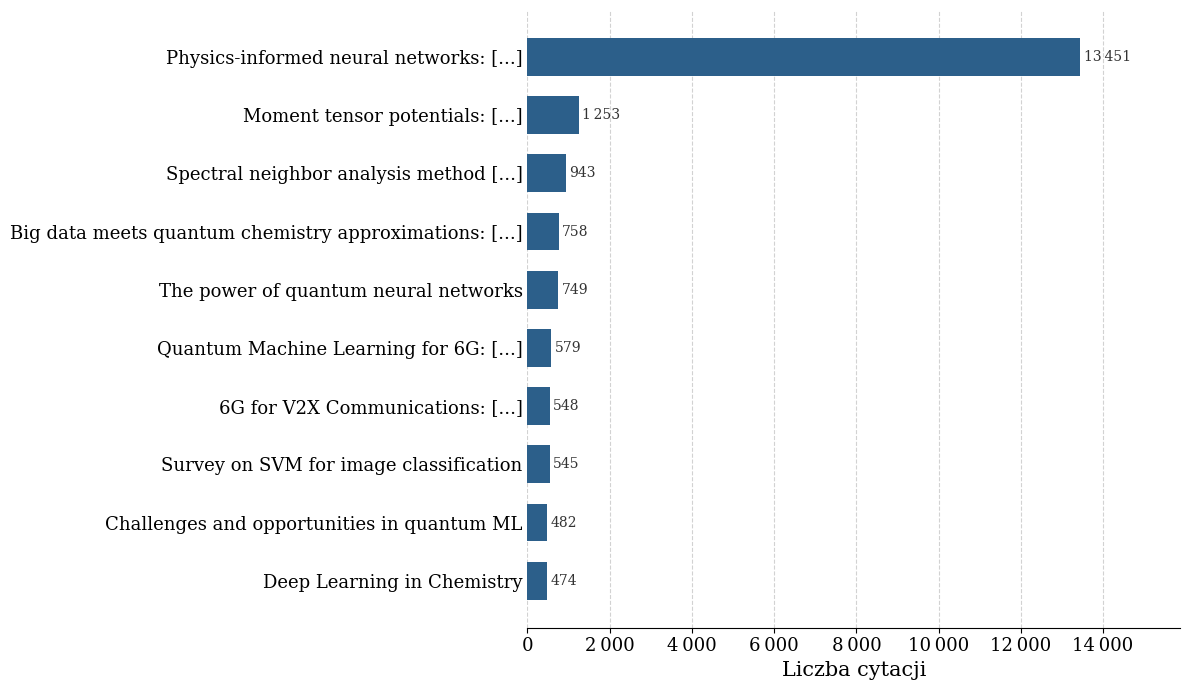

In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
	"font.family": "serif",
	"axes.titlesize": 18,
	"axes.labelsize": 15,
	"xtick.labelsize": 13,
	"ytick.labelsize": 13,
})

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
	top_df["Short Title"],
	top_df["Cited by"],
	color="#2c5f8a",
	edgecolor="none",
	height=0.65,
)

for bar in bars:
	width = bar.get_width()
	ax.text(
		width + 80,
		bar.get_y() + bar.get_height() / 2,
		f"{int(width):,}".replace(",", "\u202f"),
		va="center",
		ha="left",
		fontsize=10,
		color="#333333",
	)

ax.invert_yaxis()
ax.set_xlabel("Liczba cytacji")
ax.set_xlim(0, top_df["Cited by"].max() * 1.18)

ax.xaxis.set_major_formatter(
	mticker.FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", "\u202f"))
)

ax.grid(axis="x", linestyle="--", alpha=0.35, color="grey")
ax.set_axisbelow(True)

for spine in ["top", "right", "left"]:
	ax.spines[spine].set_visible(False)
ax.tick_params(axis="y", length=0)

plt.tight_layout()
plt.savefig(r"results\top10_cytowania.svg", format='svg', bbox_inches="tight")
plt.show()
